The following additional libraries are needed to run this
notebook. Note that running on Colab is experimental, please report a Github
issue if you have any problem.

In [ ]:
!pip install d2l==1.0.3


# Distributions
:label:`sec_distributions`

Now that we have learned how to work with probability in both the discrete and the continuous setting, let's get to know some of the common distributions encountered.  Depending on the area of machine learning, we may need to be familiar with vastly more of these, or for some areas of deep learning potentially none at all.  This is, however, a good basic list to be familiar with.  Let's first import some common libraries.


In [1]:
from mpl_toolkits import mplot3d
import torch
import torchvision
from IPython import display
from torchvision import transforms
import matplotlib.pyplot as plt

torch.pi = torch.acos(torch.zeros(1)) * 2  # Define pi in torch

## Bernoulli

This is the simplest random variable usually encountered.  This random variable encodes a coin flip which comes up $1$ with probability $p$ and $0$ with probability $1-p$.  If we have a random variable $X$ with this distribution, we will write

$$
X \sim \textrm{Bernoulli}(p).
$$

The cumulative distribution function is

$$F(x) = \begin{cases} 0 & x < 0, \\ 1-p & 0 \le x < 1, \\ 1 & x >= 1 . \end{cases}$$
:eqlabel:`eq_bernoulli_cdf`

The probability mass function is plotted below.


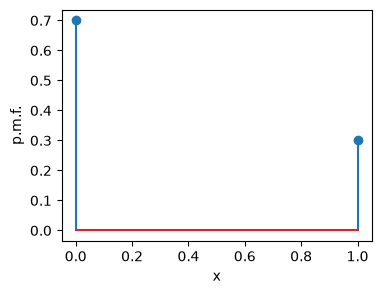

In [4]:
p = 0.3

plt.figure(figsize=(4, 3))  # width, height in inches
plt.stem([0, 1], [1 - p, p])
plt.xlabel('x')
plt.ylabel('p.m.f.')
plt.show()

Now, let's plot the cumulative distribution function :eqref:`eq_bernoulli_cdf`.


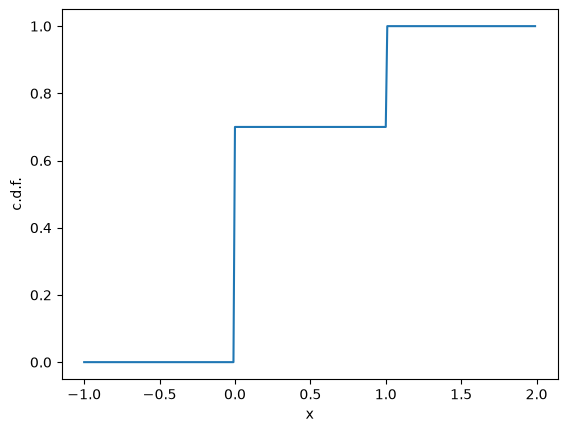

In [6]:
x = torch.arange(-1, 2, 0.01)

def F(x):
    return 0 if x < 0 else 1 if x > 1 else 1 - p

plt.plot(x, torch.tensor([F(y) for y in x]))
plt.xlabel('x')
plt.ylabel('c.d.f.')
plt.show()

If $X \sim \textrm{Bernoulli}(p)$, then:

* $\mu_X = p$,
* $\sigma_X^2 = p(1-p)$.

We can sample an array of arbitrary shape from a Bernoulli random variable as follows.


In [7]:
1*(torch.rand(10, 10) < p)

tensor([[1, 1, 1, 1, 0, 1, 0, 1, 0, 0],
        [0, 1, 1, 0, 0, 0, 0, 0, 0, 1],
        [0, 1, 0, 0, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 0, 0, 0, 1],
        [0, 0, 1, 0, 0, 1, 0, 1, 0, 1],
        [1, 1, 1, 0, 0, 1, 0, 1, 0, 0],
        [1, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [0, 1, 1, 0, 1, 0, 1, 0, 0, 0]])

## Discrete Uniform

The next commonly encountered random variable is a discrete uniform.  For our discussion here, we will assume that it is supported on the integers $\{1, 2, \ldots, n\}$, however any other set of values can be freely chosen.  The meaning of the word *uniform* in this context is that every possible value is equally likely.  The probability for each value $i \in \{1, 2, 3, \ldots, n\}$ is $p_i = \frac{1}{n}$.  We will denote a random variable $X$ with this distribution as

$$
X \sim U(n).
$$

The cumulative distribution function is

$$F(x) = \begin{cases} 0 & x < 1, \\ \frac{k}{n} & k \le x < k+1 \textrm{ with } 1 \le k < n, \\ 1 & x >= n . \end{cases}$$
:eqlabel:`eq_discrete_uniform_cdf`

Let's first plot the probability mass function.


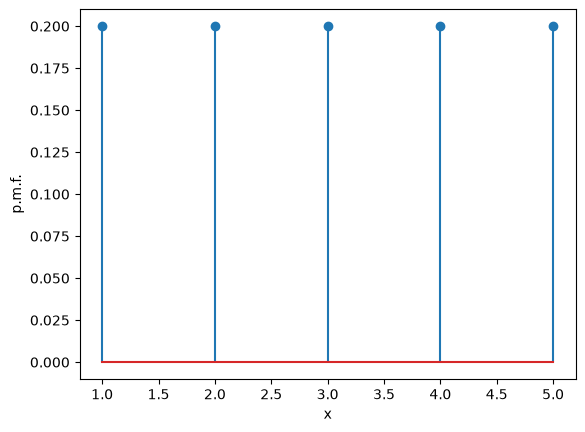

In [36]:
n = 5

plt.stem([i+1 for i in range(n)], n*[1 / n])
plt.xlabel('x')
plt.ylabel('p.m.f.')
plt.show()

Now, let's plot the cumulative distribution function :eqref:`eq_discrete_uniform_cdf`.


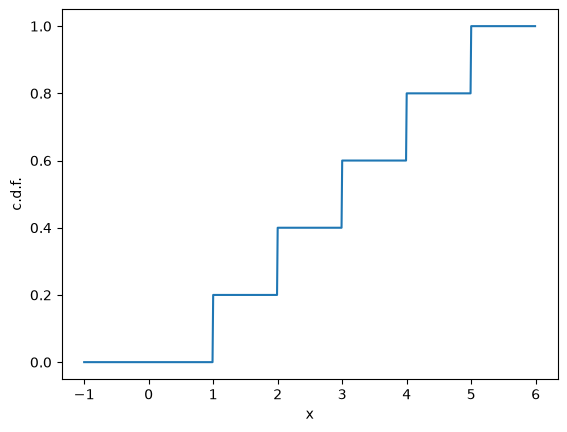

In [9]:
x = torch.arange(-1, 6, 0.01)

def F(x):
    return 0 if x < 1 else 1 if x > n else torch.floor(x) / n

plt.plot(x, torch.tensor([F(y) for y in x]))
plt.xlabel('x')
plt.ylabel('c.d.f.')
plt.show()

If $X \sim U(n)$, then:

* $\mu_X = \frac{1+n}{2}$,
* $\sigma_X^2 = \frac{n^2-1}{12}$.

We can sample an array of arbitrary shape from a discrete uniform random variable as follows.


In [ ]:
torch.randint(1, n, size=(10, 10))

tensor([[1, 4, 3, 2, 1, 1, 3, 1, 1, 4],
        [4, 1, 1, 4, 4, 1, 4, 3, 2, 4],
        [2, 4, 4, 1, 4, 2, 4, 3, 2, 1],
        [1, 2, 3, 1, 1, 4, 2, 4, 1, 3],
        [1, 2, 4, 1, 4, 3, 3, 2, 2, 1],
        [1, 2, 2, 4, 1, 3, 2, 4, 2, 3],
        [1, 2, 3, 4, 1, 3, 4, 1, 4, 3],
        [3, 1, 1, 4, 4, 1, 3, 1, 1, 2],
        [2, 2, 4, 3, 4, 2, 3, 4, 2, 4],
        [1, 4, 3, 3, 2, 3, 3, 4, 1, 3]])

## Continuous Uniform

Next, let's discuss the continuous uniform distribution. The idea behind this random variable is that if we increase the $n$ in the discrete uniform distribution, and then scale it to fit within the interval $[a, b]$, we will approach a continuous random variable that just picks an arbitrary value in $[a, b]$ all with equal probability.  We will denote this distribution as

$$
X \sim U(a, b).
$$

The probability density function is

$$p(x) = \begin{cases} \frac{1}{b-a} & x \in [a, b], \\ 0 & x \not\in [a, b].\end{cases}$$
:eqlabel:`eq_cont_uniform_pdf`

The cumulative distribution function is

$$F(x) = \begin{cases} 0 & x < a, \\ \frac{x-a}{b-a} & x \in [a, b], \\ 1 & x >= b . \end{cases}$$
:eqlabel:`eq_cont_uniform_cdf`

Let's first plot the probability density function :eqref:`eq_cont_uniform_pdf`.


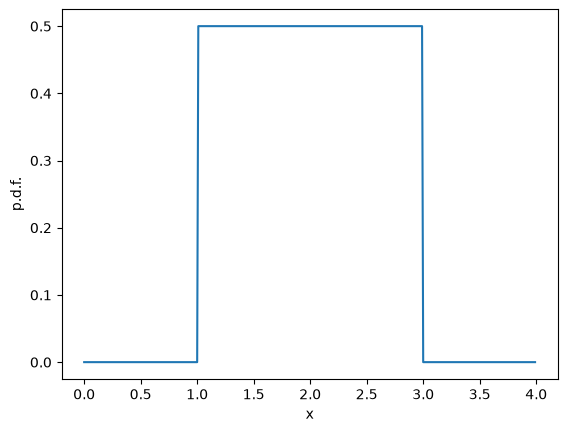

In [10]:
a, b = 1, 3

x = torch.arange(0, 4, 0.01)
p = (x > a).type(torch.float32)*(x < b).type(torch.float32)/(b-a)
plt.plot(x, p)
plt.xlabel('x')
plt.ylabel('p.d.f.')
plt.show()

Now, let's plot the cumulative distribution function :eqref:`eq_cont_uniform_cdf`.


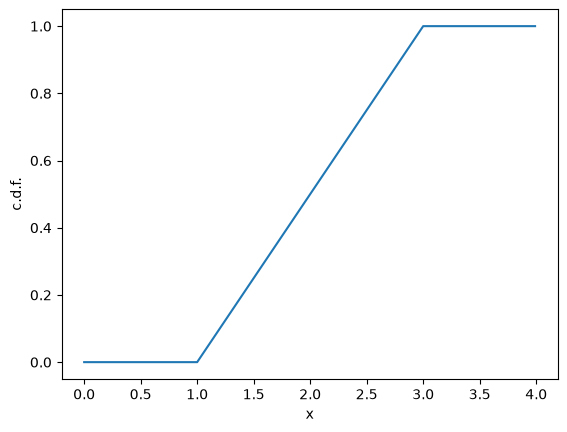

In [12]:
def F(x):
    return 0 if x < a else 1 if x > b else (x - a) / (b - a)

plt.plot(x, torch.tensor([F(y) for y in x]))
plt.xlabel('x')
plt.ylabel('c.d.f.')
plt.show()

If $X \sim U(a, b)$, then:

* $\mu_X = \frac{a+b}{2}$,
* $\sigma_X^2 = \frac{(b-a)^2}{12}$.

We can sample an array of arbitrary shape from a uniform random variable as follows.  Note that it by default samples from a $U(0,1)$, so if we want a different range we need to scale it.


In [ ]:
(b - a) * torch.rand(10, 10) + a

tensor([[2.4857, 2.2461, 1.6809, 2.7434, 2.7072, 2.6190, 1.4883, 1.2517, 1.3454,
         2.4754],
        [1.0974, 1.5680, 1.8788, 2.8231, 2.1695, 2.6461, 1.4914, 1.4887, 1.3860,
         1.9090],
        [1.3746, 1.7773, 1.2412, 1.1950, 2.7281, 2.8356, 1.2266, 2.4724, 2.4641,
         2.8991],
        [2.4018, 2.6727, 1.0308, 1.1951, 1.9390, 1.6486, 2.8314, 1.1025, 1.3354,
         1.0130],
        [1.1281, 1.8000, 2.3788, 2.6580, 1.6750, 2.2081, 1.2705, 1.0757, 2.3311,
         2.6557],
        [2.9912, 1.2263, 1.8115, 1.5940, 1.9321, 1.6469, 2.2990, 2.1473, 1.8165,
         1.2806],
        [1.1672, 1.1536, 1.9649, 2.1655, 1.7170, 1.0284, 1.3305, 2.1904, 1.4036,
         2.1958],
        [2.5891, 2.5840, 2.2679, 2.0687, 2.9249, 1.6741, 1.2238, 2.4463, 2.2235,
         2.7038],
        [1.8697, 2.4965, 1.5785, 2.7890, 2.3319, 2.1434, 2.3333, 1.0286, 1.9245,
         1.7640],
        [1.2504, 1.7558, 1.4322, 1.5226, 1.3380, 1.1388, 1.8707, 2.2330, 2.3818,
         2.2087]])

## Binomial

Let's make things a little more complex and examine the *binomial* random variable.  This random variable originates from performing a sequence of $n$ independent experiments, each of which has probability $p$ of succeeding, and asking how many successes we expect to see.

Let's express this mathematically.  Each experiment is an independent random variable $X_i$ where we will use $1$ to encode success, and $0$ to encode failure.  Since each is an independent coin flip which is successful with probability $p$, we can say that $X_i \sim \textrm{Bernoulli}(p)$.  Then, the binomial random variable is

$$
X = \sum_{i=1}^n X_i.
$$

In this case, we will write

$$
X \sim \textrm{Binomial}(n, p).
$$

To get the cumulative distribution function, we need to notice that getting exactly $k$ successes can occur in $\binom{n}{k} = \frac{n!}{k!(n-k)!}$ ways each of which has a probability of $p^k(1-p)^{n-k}$ of occurring.  Thus the cumulative distribution function is

$$F(x) = \begin{cases} 0 & x < 0, \\ \sum_{m \le k} \binom{n}{m} p^m(1-p)^{n-m}  & k \le x < k+1 \textrm{ with } 0 \le k < n, \\ 1 & x >= n . \end{cases}$$
:eqlabel:`eq_binomial_cdf`

Let's first plot the probability mass function.


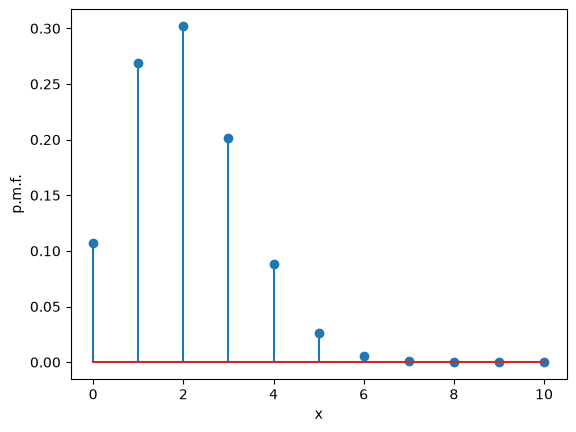

In [15]:
n, p = 10, 0.2

# Compute binomial coefficient
def binom(n, k):
    comb = 1
    for i in range(min(k, n - k)):
        comb = comb * (n - i) // (i + 1)
    return comb

pmf = torch.tensor([p**i * (1-p)**(n - i) * binom(n, i) for i in range(n + 1)])

plt.stem([i for i in range(n + 1)], pmf)
plt.xlabel('x')
plt.ylabel('p.m.f.')
plt.show()

Now, let's plot the cumulative distribution function :eqref:`eq_binomial_cdf`.


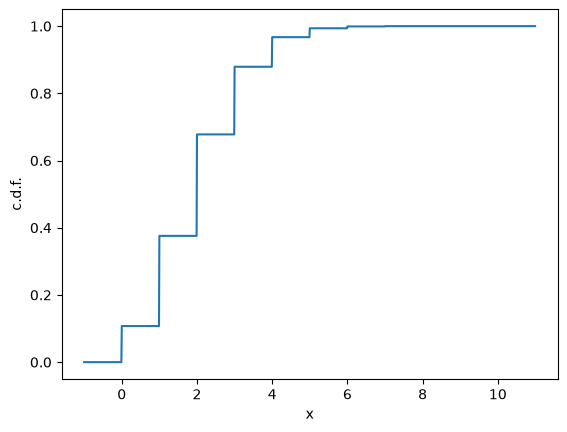

In [16]:
x = torch.arange(-1, 11, 0.01)
cmf = torch.cumsum(pmf, dim=0)

def F(x):
    return 0 if x < 0 else 1 if x > n else cmf[int(x)]

plt.plot(x, torch.tensor([F(y) for y in x.tolist()]))
plt.xlabel('x')
plt.ylabel('c.d.f.')
plt.show()

If $X \sim \textrm{Binomial}(n, p)$, then:

* $\mu_X = np$,
* $\sigma_X^2 = np(1-p)$.

This follows from the linearity of expected value over the sum of $n$ Bernoulli random variables, and the fact that the variance of the sum of independent random variables is the sum of the variances. This can be sampled as follows.


In [18]:
m = torch.distributions.binomial.Binomial(n, p)
m.sample(sample_shape=(10, 10))

tensor([[1., 3., 3., 4., 3., 1., 1., 1., 1., 2.],
        [3., 1., 1., 3., 4., 3., 3., 2., 3., 2.],
        [2., 1., 2., 1., 1., 3., 3., 1., 2., 2.],
        [2., 2., 1., 4., 2., 0., 2., 2., 2., 1.],
        [0., 3., 3., 0., 4., 1., 2., 3., 2., 0.],
        [1., 2., 2., 1., 2., 0., 1., 2., 3., 1.],
        [3., 2., 0., 2., 1., 1., 3., 3., 0., 1.],
        [3., 3., 1., 3., 3., 2., 0., 1., 2., 2.],
        [5., 3., 1., 3., 3., 4., 2., 2., 3., 2.],
        [1., 3., 1., 3., 2., 1., 2., 2., 0., 2.]])

## Poisson
Let's now perform a thought experiment.  We are standing at a bus stop and we want to know how many buses will arrive in the next minute.  Let's start by considering $X^{(1)} \sim \textrm{Bernoulli}(p)$ which is simply the probability that a bus arrives in the one minute window.  For bus stops far from an urban center, this might be a pretty good approximation.  We may never see more than one bus in a minute.

However, if we are in a busy area, it is possible or even likely that two buses will arrive.  We can model this by splitting our random variable into two parts for the first 30 seconds, or the second 30 seconds.  In this case we can write

$$
X^{(2)} \sim X^{(2)}_1 + X^{(2)}_2,
$$

where $X^{(2)}$ is the total sum, and $X^{(2)}_i \sim \textrm{Bernoulli}(p/2)$.  The total distribution is then $X^{(2)} \sim \textrm{Binomial}(2, p/2)$.

Why stop here?  Let's continue to split that minute into $n$ parts.  By the same reasoning as above, we see that

$$X^{(n)} \sim \textrm{Binomial}(n, p/n).$$
:eqlabel:`eq_eq_poisson_approx`

Consider these random variables.  By the previous section, we know that :eqref:`eq_eq_poisson_approx` has mean $\mu_{X^{(n)}} = n(p/n) = p$, and variance $\sigma_{X^{(n)}}^2 = n(p/n)(1-(p/n)) = p(1-p/n)$.  If we take $n \rightarrow \infty$, we can see that these numbers stabilize to $\mu_{X^{(\infty)}} = p$, and variance $\sigma_{X^{(\infty)}}^2 = p$.  This indicates that there *could be* some random variable we can define in this infinite subdivision limit.  

This should not come as too much of a surprise, since in the real world we can just count the number of bus arrivals, however it is nice to see that our mathematical model is well defined.  This discussion can be made formal as the *law of rare events*.

Following through this reasoning carefully, we can arrive at the following model.  We will say that $X \sim \textrm{Poisson}(\lambda)$ if it is a random variable which takes the values $\{0,1,2, \ldots\}$ with probability

$$p_k = \frac{\lambda^ke^{-\lambda}}{k!}.$$
:eqlabel:`eq_poisson_mass`

The value $\lambda > 0$ is known as the *rate* (or the *shape* parameter), and denotes the average number of arrivals we expect in one unit of time.  

We may sum this probability mass function to get the cumulative distribution function.

$$F(x) = \begin{cases} 0 & x < 0, \\ e^{-\lambda}\sum_{m = 0}^k \frac{\lambda^m}{m!} & k \le x < k+1 \textrm{ with } 0 \le k. \end{cases}$$
:eqlabel:`eq_poisson_cdf`

Let's first plot the probability mass function :eqref:`eq_poisson_mass`.


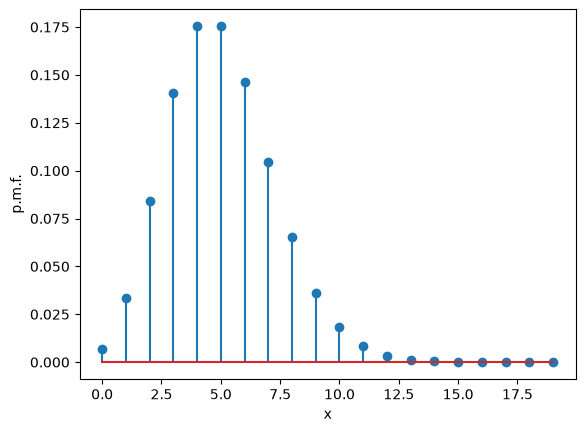

In [20]:
from math import factorial
lam = 5.0

xs = [i for i in range(20)]
pmf = torch.tensor([torch.exp(torch.tensor(-lam)) * lam**k
                    / factorial(k) for k in xs])

plt.stem(xs, pmf)
plt.xlabel('x')
plt.ylabel('p.m.f.')
plt.show()

Now, let's plot the cumulative distribution function :eqref:`eq_poisson_cdf`.


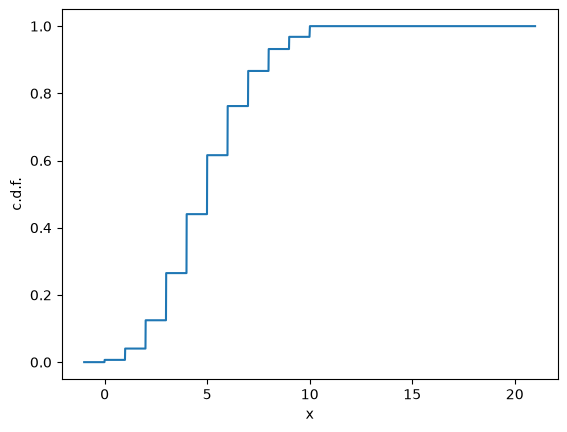

In [22]:
x = torch.arange(-1, 21, 0.01)
cmf = torch.cumsum(pmf, dim=0)
def F(x):
    return 0 if x < 0 else 1 if x > n else cmf[int(x)]

plt.plot(x, torch.tensor([F(y) for y in x.tolist()]))
plt.xlabel('x')
plt.ylabel('c.d.f.')
plt.show()

As we saw above, the means and variances are particularly concise.  If $X \sim \textrm{Poisson}(\lambda)$, then:

* $\mu_X = \lambda$,
* $\sigma_X^2 = \lambda$.

This can be sampled as follows.


In [23]:
m = torch.distributions.poisson.Poisson(lam)
m.sample((10, 10))

tensor([[11.,  4.,  4.,  3.,  4.,  8.,  2.,  7.,  4.,  1.],
        [ 3.,  6.,  9.,  1.,  9.,  3.,  4.,  8.,  7.,  4.],
        [ 5.,  6.,  2.,  2.,  9.,  4.,  3.,  5.,  8.,  5.],
        [ 1.,  4.,  6.,  3.,  5.,  4.,  5.,  8.,  3.,  5.],
        [ 3.,  4.,  7.,  5.,  9.,  4.,  3.,  5.,  7.,  5.],
        [ 7.,  2.,  3.,  5.,  1.,  4.,  5., 10.,  2.,  1.],
        [ 6.,  7.,  7.,  3.,  6.,  5.,  2.,  7.,  3.,  4.],
        [ 7.,  5.,  3.,  5.,  3.,  6.,  2.,  3.,  2.,  3.],
        [ 4.,  3.,  5.,  4.,  2.,  4.,  4.,  2.,  4., 10.],
        [ 0.,  8.,  3.,  4.,  2.,  4.,  7.,  7.,  2.,  8.]])

## Gaussian
Now Let's try a different, but related experiment.  Let's say we again are performing $n$ independent $\textrm{Bernoulli}(p)$ measurements $X_i$.  The distribution of the sum of these is $X^{(n)} \sim \textrm{Binomial}(n, p)$.  Rather than taking a limit as $n$ increases and $p$ decreases, Let's fix $p$, and then send $n \rightarrow \infty$.  In this case $\mu_{X^{(n)}} = np \rightarrow \infty$ and $\sigma_{X^{(n)}}^2 = np(1-p) \rightarrow \infty$, so there is no reason to think this limit should be well defined.

However, not all hope is lost!  Let's just make the mean and variance be well behaved by defining

$$
Y^{(n)} = \frac{X^{(n)} - \mu_{X^{(n)}}}{\sigma_{X^{(n)}}}.
$$

This can be seen to have mean zero and variance one, and so it is plausible to believe that it will converge to some limiting distribution.  If we plot what these distributions look like, we will become even more convinced that it will work.


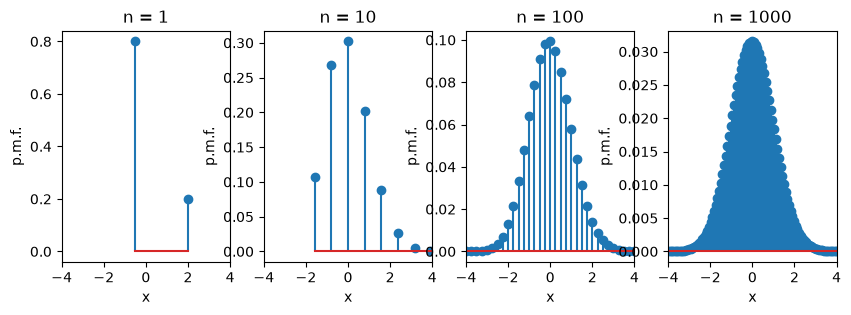

In [24]:
p = 0.2
ns = [1, 10, 100, 1000]
plt.figure(figsize=(10, 3))
for i in range(4):
    n = ns[i]
    pmf = torch.tensor([p**i * (1-p)**(n-i) * binom(n, i)
                        for i in range(n + 1)])
    plt.subplot(1, 4, i + 1)
    plt.stem([(i - n*p)/torch.sqrt(torch.tensor(n*p*(1 - p)))
                  for i in range(n + 1)], pmf)
    plt.xlim([-4, 4])
    plt.xlabel('x')
    plt.ylabel('p.m.f.')
    plt.title("n = {}".format(n))
plt.show()

One thing to note: compared to the Poisson case, we are now dividing by the standard deviation which means that we are squeezing the possible outcomes into smaller and smaller areas.  This is an indication that our limit will no longer be discrete, but rather continuous.

A derivation of what occurs is beyond the scope of this document, but the *central limit theorem* states that as $n \rightarrow \infty$, this will yield the Gaussian Distribution (or sometimes normal distribution).  More explicitly, for any $a, b$:

$$
\lim_{n \rightarrow \infty} P(Y^{(n)} \in [a, b]) = P(\mathcal{N}(0,1) \in [a, b]),
$$

where we say a random variable is normally distributed with given mean $\mu$ and variance $\sigma^2$, written $X \sim \mathcal{N}(\mu, \sigma^2)$ if $X$ has density

$$p_X(x) = \frac{1}{\sqrt{2\pi\sigma^2}}e^{-\frac{(x-\mu)^2}{2\sigma^2}}.$$
:eqlabel:`eq_gaussian_pdf`

Let's first plot the probability density function :eqref:`eq_gaussian_pdf`.


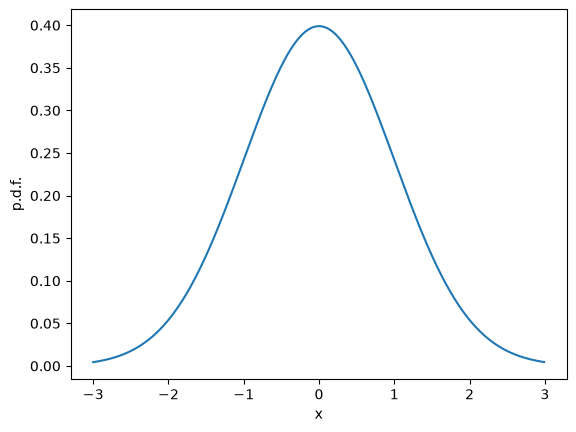

In [26]:
mu, sigma = 0, 1

x = torch.arange(-3, 3, 0.01)
p = 1 / torch.sqrt(2 * torch.pi * sigma**2) * torch.exp(
    -(x - mu)**2 / (2 * sigma**2))

plt.plot(x, p)
plt.xlabel('x')
plt.ylabel('p.d.f.')
plt.show()

Now, let's plot the cumulative distribution function.  It is beyond the scope of this appendix, but the Gaussian c.d.f. does not have a closed-form formula in terms of more elementary functions.  We will use `erf` which provides a way to compute this integral numerically.


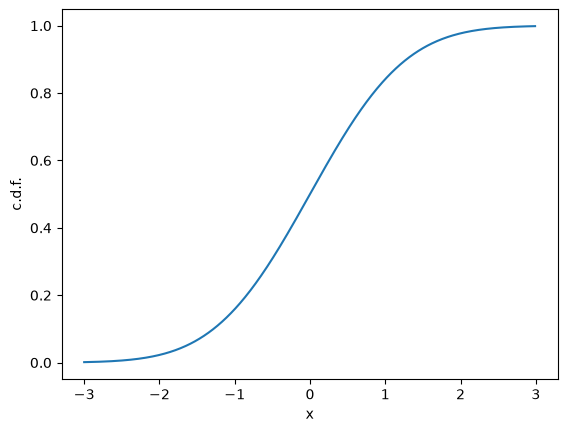

In [28]:
from math import erf
def phi(x):
    return (1.0 + erf((x - mu) / (sigma * torch.sqrt(torch.tensor(2.))))) / 2.0

plt.plot(x, torch.tensor([phi(y) for y in x.tolist()]))
plt.xlabel('x')
plt.ylabel('c.d.f.')
plt.show()

Keen-eyed readers will recognize some of these terms.  Indeed, we encountered this integral in :numref:`sec_integral_calculus`.  Indeed we need exactly that computation to see that this $p_X(x)$ has total area one and is thus a valid density.

Our choice of working with coin flips made computations shorter, but nothing about that choice was fundamental.  Indeed, if we take any collection of independent identically distributed random variables $X_i$, and form

$$
X^{(N)} = \sum_{i=1}^N X_i.
$$

Then

$$
\frac{X^{(N)} - \mu_{X^{(N)}}}{\sigma_{X^{(N)}}}
$$

will be approximately Gaussian.  There are additional requirements needed to make it work, most commonly $E[X^4] < \infty$, but the philosophy is clear.

The central limit theorem is the reason why the Gaussian is fundamental to probability, statistics, and machine learning.  Whenever we can say that something we measured is a sum of many small independent contributions, we can assume that the thing being measured will be close to Gaussian.  

There are many more fascinating properties of Gaussians, and we would like to discuss one more here.  The Gaussian is what is known as a *maximum entropy distribution*.  We will get into entropy more deeply in :numref:`sec_information_theory`, however all we need to know at this point is that it is a measure of randomness.  In a rigorous mathematical sense, we can think of the Gaussian as the *most* random choice of random variable with fixed mean and variance.  Thus, if we know that our random variable has some mean and variance, the Gaussian is in a sense the most conservative choice of distribution we can make.

To close the section, let's recall that if $X \sim \mathcal{N}(\mu, \sigma^2)$, then:

* $\mu_X = \mu$,
* $\sigma_X^2 = \sigma^2$.

We can sample from the Gaussian (or standard normal) distribution as shown below.


In [29]:
torch.normal(mu, sigma, size=(10, 10))

tensor([[-1.1748, -0.1726, -0.1632, -0.6570,  0.8178,  0.5756, -0.4105, -1.4310,
         -0.6451,  0.9327],
        [-0.1795, -0.2519,  0.5358,  1.1852, -0.7095, -1.3696,  1.0857,  0.5475,
         -1.0266, -1.1215],
        [-0.3928, -1.7462, -2.1271, -2.1004,  0.0674, -1.0450,  0.5081, -0.7789,
          1.7161, -0.1795],
        [-0.0161,  0.0103,  0.7547, -0.2408, -0.9378,  0.2470,  0.4923,  0.1153,
         -1.1822, -0.1272],
        [-1.7034, -1.0195,  0.3326, -2.4078,  0.0539, -0.5288, -0.1168,  0.4293,
         -0.4958, -0.0579],
        [-0.3045,  1.4503, -1.2806,  0.1870,  0.6500,  0.2100,  1.0171,  0.8077,
         -0.1604, -0.5469],
        [ 0.4722,  1.8389, -0.1897, -0.6618, -0.8608,  0.1731,  0.1239,  0.0643,
          1.4850, -0.1211],
        [ 0.2064,  0.1499, -1.3014, -3.2256, -0.1706,  0.9025, -1.2791, -1.3699,
         -1.0696,  1.7142],
        [ 0.8364, -2.6941, -1.9368,  0.6357,  0.5267, -0.8299,  1.7091,  0.1844,
          0.5787,  2.3454],
        [ 0.3894, -

## Exponential Family
:label:`subsec_exponential_family`

One shared property for all the distributions listed above is that they all
belong to which is known as the *exponential family*. The exponential family
is a set of distributions whose density can be expressed in the following
form:

$$p(\mathbf{x} \mid \boldsymbol{\eta}) = h(\mathbf{x}) \cdot \exp \left( \boldsymbol{\eta}^{\top} \cdot T(\mathbf{x}) - A(\boldsymbol{\eta}) \right)$$
:eqlabel:`eq_exp_pdf`

As this definition can be a little subtle, let's examine it closely.  

First, $h(\mathbf{x})$ is known as the *underlying measure* or the
*base measure*.  This can be viewed as an original choice of measure we are
modifying with our exponential weight.  

Second, we have the vector $\boldsymbol{\eta} = (\eta_1, \eta_2, ..., \eta_l) \in
\mathbb{R}^l$ called the *natural parameters* or *canonical parameters*.  These
define how the base measure will be modified.  The natural parameters enter
into the new measure by taking the dot product of these parameters against
some function $T(\cdot)$ of $\mathbf{x}= (x_1, x_2, ..., x_n) \in
\mathbb{R}^n$ and exponentiated. The vector $T(\mathbf{x})= (T_1(\mathbf{x}),
T_2(\mathbf{x}), ..., T_l(\mathbf{x}))$
is called the *sufficient statistics* for $\boldsymbol{\eta}$. This name is used since the
information represented by $T(\mathbf{x})$ is sufficient to calculate the
probability density and no other information from the sample $\mathbf{x}$'s
are required.

Third, we have $A(\boldsymbol{\eta})$, which is referred to as the *cumulant
function*, which ensures that the above distribution :eqref:`eq_exp_pdf`
integrates to one, i.e.,

$$A(\boldsymbol{\eta})  = \log \left[\int h(\mathbf{x}) \cdot \exp
\left(\boldsymbol{\eta}^{\top} \cdot T(\mathbf{x}) \right) d\mathbf{x} \right].$$

To be concrete, let's consider the Gaussian. Assuming that $\mathbf{x}$ is
an univariate variable, we saw that it had a density of

$$
\begin{aligned}
p(x \mid \mu, \sigma) &= \frac{1}{\sqrt{2 \pi \sigma^2}} \cdot \exp
\left\{ \frac{-(x-\mu)^2}{2 \sigma^2} \right\} \\
&= \frac{1}{\sqrt{2 \pi}} \cdot \exp \left\{ \frac{\mu}{\sigma^2}x
-\frac{1}{2 \sigma^2} x^2 - \left( \frac{1}{2 \sigma^2} \mu^2
+\log(\sigma) \right) \right\}.
\end{aligned}
$$

This matches the definition of the exponential family with:

* *underlying measure*: $h(x) = \frac{1}{\sqrt{2 \pi}}$,
* *natural parameters*: $\boldsymbol{\eta} = \begin{bmatrix} \eta_1 \\ \eta_2
\end{bmatrix} = \begin{bmatrix} \frac{\mu}{\sigma^2} \\
\frac{1}{2 \sigma^2} \end{bmatrix}$,
* *sufficient statistics*: $T(x) = \begin{bmatrix}x\\-x^2\end{bmatrix}$, and
* *cumulant function*: $A({\boldsymbol\eta}) = \frac{1}{2 \sigma^2} \mu^2 + \log(\sigma)
= \frac{\eta_1^2}{4 \eta_2} - \frac{1}{2}\log(2 \eta_2)$.

It is worth noting that the exact choice of each of above terms is somewhat
arbitrary.  Indeed, the important feature is that the distribution can be
expressed in this form, not the exact form itself.

As we allude to in :numref:`subsec_softmax_and_derivatives`, a widely used
technique is to assume that the  final output $\mathbf{y}$ follows an
exponential family distribution. The exponential family is a common and
powerful family of distributions encountered frequently in machine learning.


## Summary
* Bernoulli random variables can be used to model events with a yes/no outcome.
* Discrete uniform distributions model selects from a finite set of possibilities.
* Continuous uniform distributions select from an interval.
* Binomial distributions model a series of Bernoulli random variables, and count the number of successes.
* Poisson random variables model the arrival of rare events.
* Gaussian random variables model the result of adding a large number of independent random variables together.
* All the above distributions belong to exponential family.

## Exercises

1. What is the standard deviation of a random variable that is the difference $X-Y$ of two independent binomial random variables $X, Y \sim \textrm{Binomial}(16, 1/2)$.
2. If we take a Poisson random variable $X \sim \textrm{Poisson}(\lambda)$ and consider $(X - \lambda)/\sqrt{\lambda}$ as $\lambda \rightarrow \infty$, we can show that this becomes approximately Gaussian.  Why does this make sense?
3. What is the probability mass function for a sum of two discrete uniform random variables on $n$ elements?


[Discussions](https://discuss.d2l.ai/t/1098)


## 1. Core Foundational Concepts - Notes

### Probability Mass Function (PMF)
A **Probability Mass Function (PMF)** is a mathematical function that provides the **exact probability** that a **discrete random variable** is exactly equal to a specific value.
* **Variable Type:** Discrete (countable individual outcomes like rolling a die, tossing a coin, or vocabulary indices).
* **Golden Rule:** The sum of all individual probabilities must equal exactly 1.
  $$\sum_{x} P(X = x) = 1$$
* **Graphical Representation:** Separate individual spikes, dots, or vertical bars at each valid outcome.

### Probability Density Function (PDF)
A **Probability Density Function (PDF)** is a function that describes the relative likelihood of a **continuous random variable** falling within a given range.
* **Variable Type:** Continuous (infinite fractional measurements like weight, time, or temperature).
* **Crucial Rule:** The probability of a continuous variable hitting a single, infinitely exact decimal value is technically **zero** ($P(X = x) = 0$). Instead, probability is determined by calculating the **area under the curve** over a specified range.
* **Golden Rules:**
  1. The density curve can never go below zero ($f(x) \ge 0$).
  2. The total area under the entire curve must integrate to exactly 1.
  $$P(a \le X \le b) = \int_{a}^{b} f(x) \,dx$$

### Cumulative Distribution Function (CDF)
A **Cumulative Distribution Function (CDF)** measures the accumulated probability that a random variable will take a value **less than or equal to** a specific value $x$.
* **Applies to:** Both discrete and continuous variables.
* **Mathematical Definition:**
  $$F(x) = P(X \le x)$$
* **Behavior Constraints:**
  * It always starts at **0.0** (at $-\infty$).
  * It always ends at **1.0** (at $+\infty$).
  * It is **non-decreasing**: moving left-to-right, the curve can stay flat or climb, but it can never descend.

---

## 2. Summary Comparison Matrix

| Property | Probability Mass Function (PMF) | Probability Density Function (PDF) | Cumulative Distribution Function (CDF) |
| :--- | :--- | :--- | :--- |
| **Data Scope** | Discrete Variables | Continuous Variables | Both Discrete and Continuous |
| **Y-Axis Value** | Exact direct probability of an outcome. | Probability *Density* per unit (not direct probability). | Direct cumulative probability ($\le x$). |
| **Mathematical Tool** | Summation ($\sum$) | Integration ($\int$) | Summation (Discrete) or Integration (Continuous) |
| **Total Sum Constraint** | $\sum P(x) = 1$ | $\int_{-\infty}^{\infty} f(x)\,dx = 1$ | Ranges from $0 \rightarrow 1$ |

---

## 3. Practical Implementations and Graphical Analysis

Below are specific textbook code implementations and walkthroughs explaining exactly how to interpret their corresponding graphs.

### Case 1: The Discrete CDF (Bernoulli Distribution)

#### PyTorch Code Implementation
```python
import torch
from d2l import torch as d2l

# Bernoulli parameter: p = P(X = 1), the probability of success
p = 0.3

# Sample range across the outcome space
x = torch.arange(-1, 2, 0.01)

# Bernoulli CDF: P(X = 0) = 1 - p = 0.7, P(X = 1) = p = 0.3
def F(x):
    return 0 if x < 0 else 1 if x >= 1 else 1 - p

# Visualization command
d2l.plot(x, torch.tensor([F(y) for y in x]), 'x', 'c.d.f.')
```

#### Visual Interpretation Guide
* **The Step-Function Shape:** Because the distribution is discrete, the curve resembles a staircase. The values jump instantly at the exact points where an outcome is possible ($x=0$ and $x=1$).
* **Reading the First Step ($x = 0$):** Exactly at $x=0$, the line shoots vertically from $0.0$ to **0.7**. This visual jump indicates that the probability of obtaining a $0$ is precisely **70%**. The line stays perfectly flat between $0$ and $1$ because no fractional states exist between them.
* **Reading the Second Step ($x = 1$):** At $x=1$, the curve jumps from $0.7$ up to **1.0**. The height of this step ($1.0 - 0.7 = 0.3$) tells you that the probability of drawing a $1$ is precisely **30%**.
* **Post-Threshold Plateau:** Once the curve reaches $1.0$, all possible outcomes have been accumulated, so the function remains flat at $1.0$ permanently.

---

### Case 2: The Continuous Uniform CDF

#### PyTorch Code Implementation
```python
import torch
from d2l import torch as d2l

# Bounds of the continuous uniform distribution
a, b = 1, 3

# Range grid for charting
x = torch.arange(0, 4, 0.01)

# Continuous Uniform CDF over [a, b]
def F(x):
    return 0 if x < a else 1 if x > b else (x - a) / (b - a)

# Visualization command
d2l.plot(x, torch.tensor([F(y) for y in x]), 'x', 'c.d.f.')
```

#### Visual Interpretation Guide
* **The Linear Ramp:** Unlike the discrete staircase, this continuous CDF is a smooth, piecewise-linear curve: flat, then a straight diagonal ramp, then flat again. The ramp shows probability accumulating steadily across the interval.
* **Flat Lower Boundary ($x < 1$):** The line sits completely flat at **0.0** from $x = 0$ up to $x = 1$. This means there is a $0\%$ chance that a value will appear below $1$.
* **The Accumulation Ramp ($1 \le x \le 3$):** Between $1$ and $3$, the line climbs linearly. To find the probability that a value falls at or below a certain threshold, track the number on the x-axis straight up to the diagonal line, then read across to the y-axis:
  * At $x = 2$ (the midpoint), the y-axis reads exactly **0.5**, meaning there is a **50% probability** the variable is $\le 2$.
  * At $x = 1.5$, the y-axis reads **0.25** (**25% probability**).
* **Flat Upper Boundary ($x > 3$):** The line hits maximum accumulation at $x = 3$. From that point onward, the value is locked at **1.0**, because it is certain that any selected value will be less than or equal to $3$.

---

### Case 3: The Continuous Uniform PDF

#### PyTorch Code Implementation
```python
import torch
from d2l import torch as d2l

# Bounds of the continuous uniform distribution
a, b = 1, 3

# Range grid for charting
x = torch.arange(0, 4, 0.01)

# Vectorized PDF: 1/(b - a) inside [a, b], 0 elsewhere
p = ((x >= a) & (x <= b)).type(torch.float32) / (b - a)

# Visualization command
d2l.plot(x, p, 'x', 'p.d.f.')
```

#### Visual Interpretation Guide
* **The Uniform Block Shape:** This PDF forms a flat rectangle over the active interval, meaning all sub-intervals of equal length within this window are equally likely.
* **Reading Density vs. Probability:** The y-axis shows a constant height of **0.5** between $x=1$ and $x=3$. Remember that the height itself is *not* a direct probability.
* **Calculating Probability via Area:** To determine actual probability, calculate the area under the line ($\text{Width} \times \text{Height}$):
  * **Total Area Check:** The distance from $1$ to $3$ is $2$ units wide. The height is $0.5$. $\text{Total Area} = 2 \times 0.5 = 1.0$ ($100\%$ total probability).
  * **Interval Query:** To find the chance of the variable landing between $x=1$ and $x=2$, take the area of that segment: $\text{Width} = 1$, $\text{Height} = 0.5$, so $\text{Area} = 1 \times 0.5 = 0.5$, a **50% probability**.
* **Zero-Probability Regions:** Outside the $[1, 3]$ bounds, the line stays at $0.0$, indicating those regions have zero probability of occurring.

---

### Case 4: The Discrete PMF (Bernoulli Distribution)

#### Python Code Implementation
```python
import matplotlib.pyplot as plt

p = 0.3

plt.figure(figsize=(4, 3))  # width, height in inches
plt.stem([0, 1], [1 - p, p])
plt.xlabel('x')
plt.ylabel('p.m.f.')
plt.show()
```

#### Visual Interpretation Guide
To read a PMF graph, look at the heights of the individual vertical lines, which show the exact probability of each distinct outcome. This graph visualizes a Bernoulli distribution (like a weighted coin flip) with success probability $p = 0.3$.

* **The X-Axis (Discrete Outcomes):** The horizontal axis lists the only possible outcomes. Only $x = 0$ and $x = 1$ carry probability; every other point is zero.
* **The Y-Axis (Exact Probabilities):** The vertical axis (p.m.f.) displays direct probability. Unlike a continuous PDF, no area calculation is needed; you read the height directly.
* **Outcome 0:** The stem reaches exactly **0.7**, a 70% chance of getting a $0$ ($1 - p$).
* **Outcome 1:** The stem reaches exactly **0.3**, a 30% chance of getting a $1$ ($p$).
* **The Baseline:** The horizontal line at $0.0$ shows there is no probability mass between or beyond the two outcomes.

#### Connection to the Case 1 CDF
* The 0.7 stem height is why the CDF staircase jumped by 0.7 at $x = 0$.
* The 0.3 stem height is why the CDF staircase made its final jump up to 1.0 at $x = 1$.
* Together they sum to exactly 1.0 ($0.7 + 0.3 = 1.0$), satisfying the golden rule of probability.

---

## 4. Deep Learning Applications

In modern neural networks, these mathematical foundations dictate how systems behave:
* **Network Weight Initializations:** Layers are routinely initialized with values sampled from uniform or normal PDFs, with variance scaled to layer size (e.g., Xavier or He initialization), to help keep gradients from exploding or vanishing during backpropagation.
* **Data Pipelines:** Shuffling selects dataset items using a discrete uniform index distribution, so every sample has an equal chance of being processed at each position in a training epoch.
* **Advanced Activations:** Transformer-based architectures (including models like GPT and BERT) commonly use the **GELU (Gaussian Error Linear Unit)** activation, computed by multiplying each input element by the CDF of the standard normal distribution: $\text{GELU}(x) = x \cdot \Phi(x)$.

## Notes

### The Bernoulli distribution — the coin flip
This is the simplest distribution in the whole section: it models a single yes/no event, like one coin flip. 

Setup: A random variable $X$ takes the value $1$ (success) with probability $p$, and $0$ (failure) with probability $1-p$. You write this as:

$$X \sim \textrm{Bernoulli}(p)$$

Why it matters intuitively: anything that's binary — did the email get clicked, did the patient recover, did the coin land heads — can be modeled this way. It's the atomic building block; more complex distributions (like Binomial) are literally built by summing many Bernoullis.

The CDF (cumulative distribution function)
$$F(x) = \begin{cases} 0 & x < 0 \\ 1-p & 0 \le x < 1 \\ 1 & x \ge 1 \end{cases}$$

Read this as: "what's the probability that $X$ is less than or equal to $x$?" Since $X$ can only be 0 or 1:

For any $x < 0$: impossible, so probability 0.
For $0 \le x < 1$: only way to be $\le x$ is if $X=0$, which happens with probability $1-p$.
For $x \ge 1$: both outcomes ($0$ and $1$) satisfy $X \le x$, so probability is 1.

This gives a step function — flat at 0, jumps up to $1-p$ at $x=0$, then jumps to $1$ at $x=1$.

Mean and variance

If $X \sim \textrm{Bernoulli}(p)$:

$\mu_X = p$
$\sigma_X^2 = p(1-p)$

$X$ — the random variable itself. Think of it as a placeholder for "the outcome of one trial," before you've actually run the trial. It's not a fixed number; it's a variable whose value is determined by chance.

**$\sim$** (tilde) — read as "is distributed as" or "follows the distribution of." It's the standard symbol statisticians use to connect a random variable to the family of distribution it belongs to. It does not mean "approximately equal to" here (a common confusion, since $\sim$ sometimes means that in other contexts) — in this context it specifically means "has this probability distribution."

$\textrm{Bernoulli}(p)$ — the name of the distribution family, with $p$ as its one parameter (a number between 0 and 1) that fully determines its shape. $p$ is the probability of getting a "success" (the outcome $1$).


#### Sampling it in code (casting the boolean to an integer via 1*)
1*(torch.rand(10, 10) < p)

## Discrete Uniform — every outcome equally likely

This is the next-simplest distribution: instead of just two outcomes (like Bernoulli), you have $n$ possible outcomes, and every single one has exactly the same probability of occurring.

**Setup:** The variable is defined over the integers $\{1, 2, \ldots, n\}$ (you could pick any other finite set, but this is the standard convention). Since it's *uniform*, each value $i$ is equally likely:

$$p_i = \frac{1}{n} \quad \text{for } i \in \{1, 2, \ldots, n\}$$

You write this as:

$$X \sim U(n)$$

**Intuition:** a fair die is the classic example — $X \sim U(6)$, where each face 1 through 6 has probability $\frac{1}{6}$. Anything with equally-likely finite outcomes fits this (a lottery draw, a random shuffle pick, etc.).

### The CDF

$$F(x) = \begin{cases} 0 & x < 1 \\ \frac{k}{n} & k \le x < k+1 \text{ with } 1 \le k < n \\ 1 & x \ge n \end{cases}$$

Same logic as before — ask "how many outcomes are $\le x$, and what's their total probability?" If $x$ sits between $k$ and $k+1$, then exactly $k$ of the $n$ equally-likely outcomes ($1, 2, \ldots, k$) satisfy "outcome $\le x$." Since each carries probability $\frac{1}{n}$, the total is $\frac{k}{n}$. This produces a *staircase* — flat steps that jump up by $\frac{1}{n}$ at each integer, unlike Bernoulli's single jump.

### Mean and variance

If $X \sim U(n)$:
- $\mu_X = \frac{1+n}{2}$
- $\sigma_X^2 = \frac{n^2-1}{12}$

The mean is just the midpoint of the range $\{1, \ldots, n\}$ — makes sense, since with everything equally likely, the average is the "center." E.g., for a fair die ($n=6$): $\mu_X = \frac{1+6}{2} = 3.5$ — matches what you'd expect (average roll over many throws).

The variance formula is less intuitive at a glance, but the key takeaway is that it *grows* as $n$ grows — more spread-out possible values means more variance, which tracks with intuition.

### Sampling it in code

```python
torch.randint(1, n, size=(10, 10))
```
This draws integers uniformly at random. One subtlety worth flagging: PyTorch's `randint(1, n, ...)` samples from $\{1, \ldots, n-1\}$ (excludes the upper bound) — so if you actually want the full range $\{1,\ldots,n\}$ as defined in the text, you'd need `randint(1, n+1, ...)`. Worth double-checking library-specific conventions like this whenever you translate a formula into code.


Let's use the fair die: $n = 6$, so $X \sim U(6)$, taking values $\{1,2,3,4,5,6\}$, each with probability $\frac{1}{6}$.

$F(x)$ answers the question: **"what's the probability the die roll is less than or equal to $x$?"** Let's plug in several values of $x$ and see how the formula matches intuition.

**Case 1: $x < 1$** (e.g., $x = 0$, or $x = 0.5$)

No possible roll is $\le 0.5$ — the smallest roll is $1$. So:
$$F(0.5) = 0$$
Matches the formula: $x < 1 \Rightarrow F(x) = 0$.

**Case 2: $x$ between $k$ and $k+1$** (e.g., $x = 3$, or $x = 3.7$)

Take $x = 3$. Which rolls satisfy "roll $\le 3$"? That's $\{1, 2, 3\}$ — exactly $k=3$ outcomes. Each has probability $\frac{1}{6}$, so:
$$F(3) = \frac{3}{6} = 0.5$$

Now take $x = 3.7$ (not even an integer). Which rolls satisfy "roll $\le 3.7$"? Still just $\{1, 2, 3\}$ — rolling a $4$ would fail ($4 \le 3.7$ is false). So $k$ is the same, and:
$$F(3.7) = \frac{3}{6} = 0.5$$

This is *why* the formula uses $\lfloor x \rfloor$-type logic (written as "$k \le x < k+1$"): $F(x)$ only changes at integer values, and stays flat in between. That's what makes it a *staircase* rather than a smooth curve.

**Case 3: $x \ge n$** (e.g., $x = 6$, or $x = 100$)

Every possible roll ($1$ through $6$) satisfies "roll $\le 6$." So:
$$F(6) = 1, \quad F(100) = 1$$
Matches the formula: $x \ge n \Rightarrow F(x) = 1$.

### Putting it together as a table

| $x$ | $F(x)$ |
|---|---|
| $-1$ | $0$ |
| $0.9$ | $0$ |
| $1$ | $1/6 \approx 0.167$ |
| $2.5$ | $2/6 \approx 0.333$ |
| $3$ | $3/6 = 0.5$ |
| $5.9$ | $5/6 \approx 0.833$ |
| $6$ | $1$ |
| $50$ | $1$ |

If you plotted this, it would look like six equal-height steps climbing from $0$ to $1$, each step $\frac{1}{6}$ tall, with jumps happening exactly at $x=1,2,3,4,5,6$ — the code snippet in the page does exactly this plot.

The general pattern to take away: for *any* discrete uniform variable, $F(x)$ at a given point just counts **how many of the possible outcomes are $\le x$**, divides by the total number of outcomes $n$, and that count only changes at the integer boundaries — hence the staircase shape.


## Continuous Uniform — stretching Discrete Uniform into a continuum

This is a direct generalization of what you just learned. Instead of picking equally-likely values from a *finite list* of integers, you now pick equally-likely values from *any real number* in an interval $[a, b]$.

**The connecting idea (from the text):** imagine taking the discrete uniform $U(n)$ and cranking $n$ up higher and higher — more and more possible values, packed closer together — while stretching/scaling that range to fit inside $[a,b]$. As $n \to \infty$, the "gaps" between possible values shrink to nothing, and you get a variable that can land *anywhere* in $[a,b]$, with no value more likely than any other.

You write this as:

$$X \sim U(a, b)$$

**Intuition:** think of a spinner that can point anywhere along a circle from $a$ to $b$ with total impartiality — no notch is favored. Or: picking a perfectly random real number between, say, 1 and 3.

### Why probability mass function (p.m.f.) becomes probability *density* function (p.d.f.)

This is the key conceptual jump from discrete to continuous. With discrete uniform, each individual outcome had a real probability ($\frac{1}{n}$). But with continuous uniform, there are *infinitely many* possible values in $[a,b]$ — so the probability of hitting any *exact* single point is actually $0$ (you can't meaningfully divide $1$ among infinitely many points and get anything nonzero). 

Instead, we talk about **density** — probability *per unit length* — and get actual probabilities only by integrating density over some range. That's why it's called a p.d.f., not a p.m.f.

### The p.d.f.

$$p(x) = \begin{cases} \frac{1}{b-a} & x \in [a,b] \\ 0 & x \notin [a,b] \end{cases}$$

This says: density is a constant, flat value of $\frac{1}{b-a}$ everywhere inside $[a,b]$, and zero outside. Why $\frac{1}{b-a}$ specifically? Because total probability must integrate to $1$: if density is constant over an interval of length $(b-a)$, then

$$\text{density} \times \text{length} = 1 \implies \text{density} = \frac{1}{b-a}$$

Concretely, for $U(1,3)$ (as in the code example, $a=1, b=3$): density $= \frac{1}{3-1} = 0.5$ everywhere between 1 and 3, and $0$ elsewhere. This is why the p.d.f. plot in the page is just a flat rectangle.

### The CDF

$$F(x) = \begin{cases} 0 & x < a \\ \frac{x-a}{b-a} & x \in [a,b] \\ 1 & x \ge b \end{cases}$$

Same interpretation as before — "what fraction of the probability lies to the left of $x$?" Since density is constant, the answer is just the *fraction of the interval* you've covered: $\frac{x-a}{b-a}$. E.g., for $U(1,3)$, at $x=2$ (the midpoint), $F(2) = \frac{2-1}{3-1} = 0.5$ — half the probability lies below the midpoint, which matches intuition for something spread evenly.

Notice: this CDF is a **straight line** ramping from 0 to 1, not a staircase — that's the visual signature of "continuous and uniform," versus the discrete case's step-jumps.

### Mean and variance

If $X \sim U(a,b)$:
- $\mu_X = \frac{a+b}{2}$ — just the midpoint of the interval. Makes sense: symmetric spread, so the average is the center.
- $\sigma_X^2 = \frac{(b-a)^2}{12}$ — grows as the interval widens (more spread possible = more variance), same intuition as the discrete case.

### Sampling it in code

```python
(b - a) * torch.rand(10, 10) + a
```
`torch.rand` gives values uniformly in $[0,1)$. To stretch this to $[a,b]$: multiply by the interval width $(b-a)$ to scale it, then shift by adding $a$. This is a standard trick — anytime you have a $U(0,1)$ generator and want $U(a,b)$, this linear transformation does it.

This section sets up nicely for Binomial next, which combines multiple Bernoullis — want to go through that, or is there a specific piece here (like why density can exceed 1, or the integral intuition) you want to dig into more?